Chargement des données pour le traitement

In [1]:
import pandas as pd
try:
    df = pd.read_csv(
        'https://www.data.gouv.fr/fr/datasets/r/182268fc-2103-4bcb-a850-6cf90b02a9eb'
    )
except Exception as e:
    print(f"Une erreur s'est produite lors de la lecture du fichier CSV: {e}")

C:\Users\Djamal TOE\AppData\Local\Temp\ipykernel_129704\912013414.py:3: DtypeWarning: Columns (0: prenom) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


In [2]:
df.sample(20)

,code_departement,libelle_departement,code_commune,libelle_commune,prenom,nom,voix
112780,21,Côte-d'Or,110,Brochon,Jean,LASSALLE,8
84447,37,Indre-et-Loire,211,Saint-Branchs,Emmanuel,MACRON,466
134539,73,Savoie,124,Gilly-sur-Isère,Jean,LASSALLE,56
188010,31,Haute-Garonne,538,Savères,Éric,ZEMMOUR,9
379622,69,Rhône,217,Saint-Just-d'Avray,Philippe,POUTOU,3
374312,59,Nord,76,Bettignies,Philippe,POUTOU,0
168468,70,Haute-Saône,262,Genevreuille,Marine,LE PEN,35
489983,81,Tarn,42,Burlats,NaN,blancs,17
152066,30,Gard,187,Navacelles,Marine,LE PEN,85
472333,38,Isère,139,Creys-Mépieu,NaN,blancs,17


## Question 1

In [3]:
# Code commune
df["code_commune"] = (
    df["code_departement"].astype(str) +
    df["code_commune"].astype(str).str.zfill(3)
)

# Candidat
df["candidat"] = df["prenom"] + " " + df["nom"]

df.head()

,code_departement,libelle_departement,code_commune,libelle_commune,prenom,nom,voix,candidat
0,01,Ain,01001,L'Abergement-Clémenciat,Nathalie,ARTHAUD,3,Nathalie ARTHAUD
1,01,Ain,01002,L'Abergement-de-Varey,Nathalie,ARTHAUD,2,Nathalie ARTHAUD
2,01,Ain,01004,Ambérieu-en-Bugey,Nathalie,ARTHAUD,38,Nathalie ARTHAUD
3,01,Ain,01005,Ambérieux-en-Dombes,Nathalie,ARTHAUD,8,Nathalie ARTHAUD
4,01,Ain,01006,Ambléon,Nathalie,ARTHAUD,0,Nathalie ARTHAUD


## Question 2

In [4]:

# On filtre le dataset pour exclure les votes non exprimés
# (ces lignes ne correspondent pas à des candidats)
df_candidats = df[~df["nom"].isin(['blancs', 'nuls', 'abstentions'])]

# Chaque candidat apparaît plusieurs fois (une ligne par commune)
# On utilise donc nunique() pour compter uniquement les candidats distincts
candidats = df_candidats["candidat"].nunique()

f"En 2022, il y avait {candidats} candidats à l'élection présidentielle."

"En 2022, il y avait 12 candidats à l'élection présidentielle."

## Question 3

In [5]:
# 1. Filtrer pour garder uniquement les votes exprimés
# (on enlève les abstentions, blancs et nuls)
df_exprimes = df[~df["nom"].isin(['blancs', 'nuls', 'abstentions'])]


# 2. Calculer le nombre total de voix par candidat
# groupby = regrouper par candidat
# sum = additionner les voix sur toutes les communes
resultats = (
    df_exprimes
    .groupby("candidat", as_index=False)["voix"]
    .sum()
)

total_exprimes = resultats["voix"].sum()

# 4. Calculer le pourcentage pour chaque candidat
# (voix du candidat / total des voix) * 100
resultats["pourcentage"] = (
    resultats["voix"] / total_exprimes * 100
).round(2)

resultats = resultats.sort_values(by="voix", ascending=False)

resultats.head(12)

,candidat,voix,pourcentage
1,Emmanuel MACRON,9783058,27.85
5,Marine LE PEN,8133828,23.15
4,Jean-Luc MÉLENCHON,7712520,21.95
11,Éric ZEMMOUR,2485226,7.07
9,Valérie PÉCRESSE,1679001,4.78
10,Yannick JADOT,1627853,4.63
3,Jean LASSALLE,1101387,3.13
2,Fabien ROUSSEL,802422,2.28
7,Nicolas DUPONT-AIGNAN,725176,2.06
0,Anne HIDALGO,616478,1.75


In [6]:
df["candidat"] = df["prenom"] + " " + df["nom"]
df.sample(10)

,code_departement,libelle_departement,code_commune,libelle_commune,prenom,nom,voix,candidat
326869,26,Drôme,26370,Vercoiran,Valérie,PÉCRESSE,7,Valérie PÉCRESSE
287664,17,Charente-Maritime,17164,Fontcouverte,Yannick,JADOT,77,Yannick JADOT
524944,80,Somme,80570,Moreuil,NaN,nuls,29,NaN
403000,40,Landes,40281,Saint-Pierre-du-Mont,Nicolas,DUPONT-AIGNAN,116,Nicolas DUPONT-AIGNAN
337329,55,Meuse,55129,Courouvre,Valérie,PÉCRESSE,4,Valérie PÉCRESSE
277671,79,Deux-Sèvres,79316,Soudan,Anne,HIDALGO,7,Anne HIDALGO
101927,80,Somme,80484,Liomer,Emmanuel,MACRON,44,Emmanuel MACRON
249350,08,Ardennes,08309,Mont-Saint-Remy,Anne,HIDALGO,0,Anne HIDALGO
180882,14,Calvados,14344,Janville,Éric,ZEMMOUR,23,Éric ZEMMOUR
394966,21,Côte-d'Or,21341,Lantilly,Nicolas,DUPONT-AIGNAN,0,Nicolas DUPONT-AIGNAN


## 2. Comparaison des scores départements aux moyennes nationales.

Q4. Créons un dataframe nommé score_departements stockant, pour chaque département, le nombre de vote obtenu pour chaque candidat et le score (en %).

In [7]:
# Votes par candidat
score_departements = df.groupby(["code_departement", "candidat"]).agg(
    votes = ("voix", "sum")
).reset_index()

# Récupération des totaux sans tenir compte des votes adressé à personne
total_dep = df.loc[~df["candidat"].isna()].groupby(["code_departement"]).agg(
    total = ("voix", "sum")
).reset_index()

# Rajout du total
score_departements = score_departements.merge(right=total_dep, how="left", on="code_departement")
score_departements


# Calcul du score
score_departements["score"] = round(100 * score_departements["votes"] / score_departements["total"], 2)  # .astype(str)  + "%"
score_departements = score_departements.drop(columns="total")

In [8]:
# affichage comme souhaité
x = score_departements.copy()
x["score"] = x["score"].astype(str)  + "%"
x

,code_departement,candidat,votes,score
0,01,Anne HIDALGO,5644,1.69%
1,01,Emmanuel MACRON,92206,27.69%
2,01,Fabien ROUSSEL,5938,1.78%
3,01,Jean LASSALLE,10876,3.27%
4,01,Jean-Luc MÉLENCHON,57832,17.37%
...,...,...,...,...
1291,fr_etranger,Nicolas DUPONT-AIGNAN,7074,1.42%
1292,fr_etranger,Philippe POUTOU,3145,0.63%
1293,fr_etranger,Valérie PÉCRESSE,20956,4.2%
1294,fr_etranger,Yannick JADOT,40774,8.17%


cellule de vérification ci-dessous avec le département 11

In [9]:
x.loc[x["code_departement"] == "11"].sort_values("votes", ascending=False)

,code_departement,candidat,votes,score
125,11,Marine LE PEN,64027,30.14%
121,11,Emmanuel MACRON,43104,20.29%
124,11,Jean-Luc MÉLENCHON,42039,19.79%
131,11,Éric ZEMMOUR,18434,8.68%
123,11,Jean LASSALLE,12382,5.83%
129,11,Valérie PÉCRESSE,7350,3.46%
130,11,Yannick JADOT,6322,2.98%
120,11,Anne HIDALGO,6166,2.9%
122,11,Fabien ROUSSEL,5622,2.65%
127,11,Nicolas DUPONT-AIGNAN,4206,1.98%


Q5. Refaissons le lien avec le niveau national pour comparer le score départemental avec le score national. Et nommons ce dataframe score_departements, nous allons le réutiliser par la suite.

In [10]:
# Votes par candidat et par département
score_departements = df.groupby(["code_departement", "candidat"]).agg(
    votes = ("voix", "sum")
).reset_index()

# Récupération des totaux sans tenir compte des votes adressé à personne
total_dep = df.loc[~df["candidat"].isna()].groupby(["code_departement"]).agg(
    total = ("voix", "sum")
).reset_index()

# Rajout du total
score_departements = score_departements.merge(right=total_dep, how="left", on="code_departement")

# Calcul du score
score_departements["score_departement"] = round(100 * score_departements["votes"] / score_departements["total"], 2)
score_departements = score_departements.drop(columns="total")
score_departements

,code_departement,candidat,votes,score_departement
0,01,Anne HIDALGO,5644,1.69
1,01,Emmanuel MACRON,92206,27.69
2,01,Fabien ROUSSEL,5938,1.78
3,01,Jean LASSALLE,10876,3.27
4,01,Jean-Luc MÉLENCHON,57832,17.37
...,...,...,...,...
1291,fr_etranger,Nicolas DUPONT-AIGNAN,7074,1.42
1292,fr_etranger,Philippe POUTOU,3145,0.63
1293,fr_etranger,Valérie PÉCRESSE,20956,4.20
1294,fr_etranger,Yannick JADOT,40774,8.17


In [11]:
# Votes par candidat
nationale = df.groupby(["candidat"]).agg(
    votes_national = ("voix", "sum")
).reset_index()

# Récupération des totaux sans tenir compte des votes adressé à personne
total_nationale = sum(df.loc[~df["candidat"].isna()]["voix"])

# Calcul du score
nationale["score_national"] = round(100 * nationale["votes_national"] / total_nationale, 2) # .astype(str)  + "%"
nationale

# Jointure avec la table relatives aux départements
score_departements = score_departements.merge(right=nationale, on="candidat", how="left")
score_departements = score_departements.rename(columns={"votes": "votes_departement", "score": "score_departement"})
score_departements

,code_departement,candidat,votes_departement,score_departement,votes_national,score_national
0,01,Anne HIDALGO,5644,1.69,616478,1.75
1,01,Emmanuel MACRON,92206,27.69,9783058,27.85
2,01,Fabien ROUSSEL,5938,1.78,802422,2.28
3,01,Jean LASSALLE,10876,3.27,1101387,3.13
4,01,Jean-Luc MÉLENCHON,57832,17.37,7712520,21.95
...,...,...,...,...,...,...
1291,fr_etranger,Nicolas DUPONT-AIGNAN,7074,1.42,725176,2.06
1292,fr_etranger,Philippe POUTOU,3145,0.63,268904,0.77
1293,fr_etranger,Valérie PÉCRESSE,20956,4.20,1679001,4.78
1294,fr_etranger,Yannick JADOT,40774,8.17,1627853,4.63


In [12]:
# Affichage comme demandé
x = score_departements.copy()
x["score_departement"] = x["score_departement"].astype(str)  + "%"
x["score_national"] = x["score_national"].astype(str)  + "%"
x

,code_departement,candidat,votes_departement,score_departement,votes_national,score_national
0,01,Anne HIDALGO,5644,1.69%,616478,1.75%
1,01,Emmanuel MACRON,92206,27.69%,9783058,27.85%
2,01,Fabien ROUSSEL,5938,1.78%,802422,2.28%
3,01,Jean LASSALLE,10876,3.27%,1101387,3.13%
4,01,Jean-Luc MÉLENCHON,57832,17.37%,7712520,21.95%
...,...,...,...,...,...,...
1291,fr_etranger,Nicolas DUPONT-AIGNAN,7074,1.42%,725176,2.06%
1292,fr_etranger,Philippe POUTOU,3145,0.63%,268904,0.77%
1293,fr_etranger,Valérie PÉCRESSE,20956,4.2%,1679001,4.78%
1294,fr_etranger,Yannick JADOT,40774,8.17%,1627853,4.63%


cellule de vérification ci-dessous avec le département 1

In [13]:
x.loc[x["code_departement"] == "11"].sort_values("votes_departement", ascending=False)

,code_departement,candidat,votes_departement,score_departement,votes_national,score_national
125,11,Marine LE PEN,64027,30.14%,8133828,23.15%
121,11,Emmanuel MACRON,43104,20.29%,9783058,27.85%
124,11,Jean-Luc MÉLENCHON,42039,19.79%,7712520,21.95%
131,11,Éric ZEMMOUR,18434,8.68%,2485226,7.07%
123,11,Jean LASSALLE,12382,5.83%,1101387,3.13%
129,11,Valérie PÉCRESSE,7350,3.46%,1679001,4.78%
130,11,Yannick JADOT,6322,2.98%,1627853,4.63%
120,11,Anne HIDALGO,6166,2.9%,616478,1.75%
122,11,Fabien ROUSSEL,5622,2.65%,802422,2.28%
127,11,Nicolas DUPONT-AIGNAN,4206,1.98%,725176,2.06%


Q6. Créons une variable surrepresentation qui compare, en relatif, les scores nationaux et départementaux

In [14]:
score_departements["surrepresentation"] = round(((score_departements["score_departement"] / score_departements["score_national"]) - 1) * 100, 2)

In [15]:
# Affichage comme demandé (avec le symbole %)
x = score_departements.copy()
x["score_departement"] = x["score_departement"].astype(str)  + "%"
x["score_national"] = x["score_national"].astype(str)  + "%"
x["surrepresentation"] = x["surrepresentation"].astype(str)  + "%"
x

,code_departement,candidat,votes_departement,score_departement,votes_national,score_national,surrepresentation
0,01,Anne HIDALGO,5644,1.69%,616478,1.75%,-3.43%
1,01,Emmanuel MACRON,92206,27.69%,9783058,27.85%,-0.57%
2,01,Fabien ROUSSEL,5938,1.78%,802422,2.28%,-21.93%
3,01,Jean LASSALLE,10876,3.27%,1101387,3.13%,4.47%
4,01,Jean-Luc MÉLENCHON,57832,17.37%,7712520,21.95%,-20.87%
...,...,...,...,...,...,...,...
1291,fr_etranger,Nicolas DUPONT-AIGNAN,7074,1.42%,725176,2.06%,-31.07%
1292,fr_etranger,Philippe POUTOU,3145,0.63%,268904,0.77%,-18.18%
1293,fr_etranger,Valérie PÉCRESSE,20956,4.2%,1679001,4.78%,-12.13%
1294,fr_etranger,Yannick JADOT,40774,8.17%,1627853,4.63%,76.46%


Q7. Créons une fonction pour représenter une figure similaire à Figure 1 pour un candidat donné des
principales surreprésentations (en valeur absolue) par département.

In [16]:
def display_surrepresentation(candidat: str, top: int=5):
    """
        Permet de représenter visuellement la surreprésentation des candidats

        Parameters
        ------------
            candidat : str
                Prenom et nom du candidat
            top : int
                le top a afficher (par défaut 5)

    """

    from matplotlib import pyplot as plt

    # Selection des données pour un candidat donné
    res = score_departements.loc[(
        (score_departements["candidat"] == candidat)
        )].sort_values(by="surrepresentation", key=abs, ascending=False).head(top) # On ordonne selon la valeur absolue de la surreprésentation

    res = res.sort_values("surrepresentation", ascending=True)

    plt.barh(y = res["code_departement"], width=res["surrepresentation"])
    plt.title("Top 5 des surreprésentation de " + candidat)
    plt.axvline(x=0)
    plt.show()

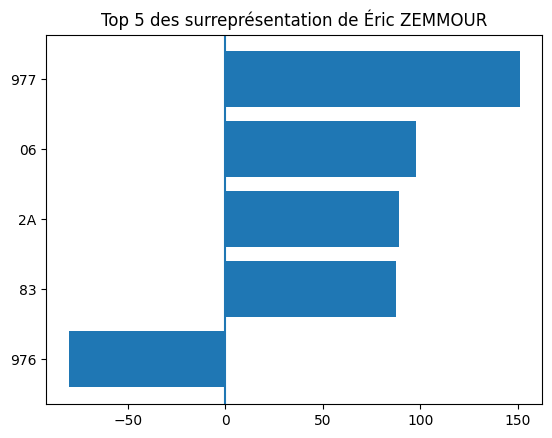

In [17]:
display_surrepresentation(candidat="Éric ZEMMOUR")

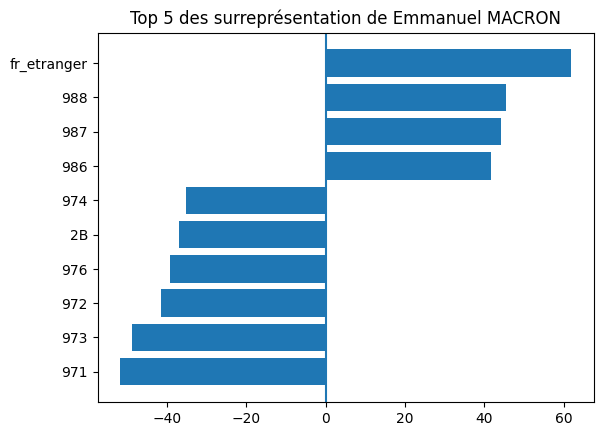

In [18]:
display_surrepresentation(candidat="Emmanuel MACRON", top=10)

## 3. Un peu de cartographie

### Question 8 : Faire une fonction permettant de restreindre score_departements en fonction d’un candidat. Commencer par tester sur Marine Le Pen (créer un nouvel objet, ne pas écraser score_departements nous allons l’utiliser à nouveau !). Faire une jointure au fond de carte des départements et effectuer une carte de la représentation

In [19]:
import numpy as np
np.max(score_departements['surrepresentation'][score_departements['candidat'].str.lower() == 'EmmaNUEL MACRON'.lower()])

61.9

In [20]:
# Importation de la classe Cartographie et téléchargement des données géographiques
from Modules.cartographie import Cartographie
cartographie = Cartographie()
cartographie.download_departement_borders()

e:\ENSAI\2A\semestre2\python_4_data_science\venv1\Lib\site-packages\matplotlib_scalebar\scalebar.py:457: UserWarning: Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the warning with rotation='horizontal-only'.
  warnings.warn(


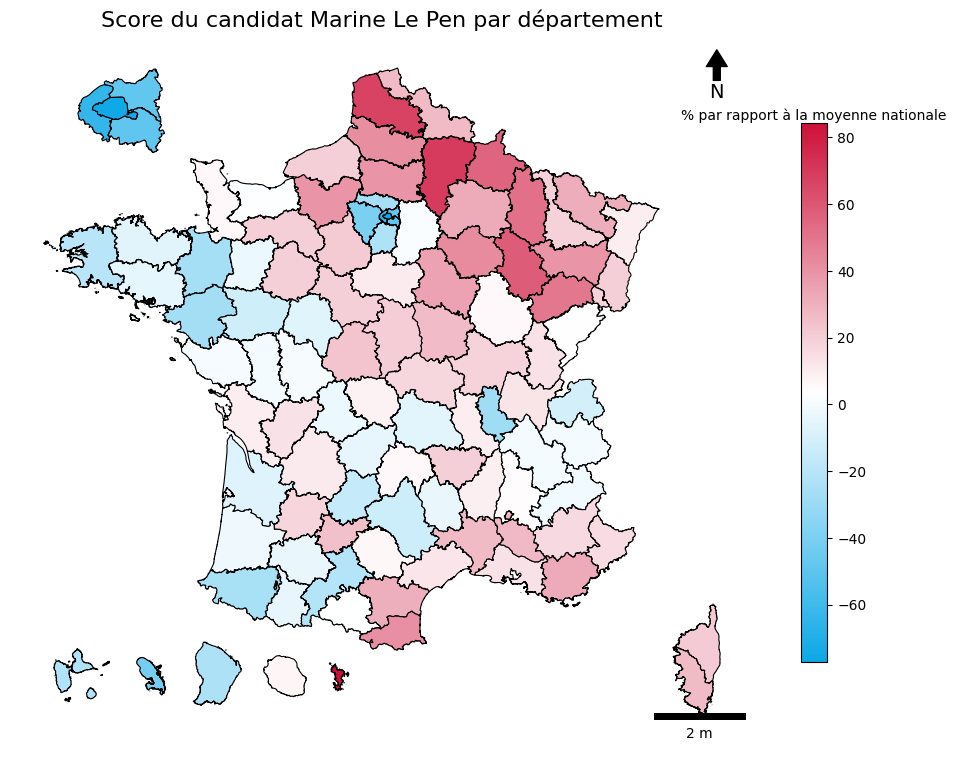

In [21]:
cartographie.afficher_resultats_filtre_candidat(df_score=score_departements, candidat="Marine Le Pen", afficher_carte=True)

e:\ENSAI\2A\semestre2\python_4_data_science\venv1\Lib\site-packages\matplotlib_scalebar\scalebar.py:457: UserWarning: Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the warning with rotation='horizontal-only'.
  warnings.warn(


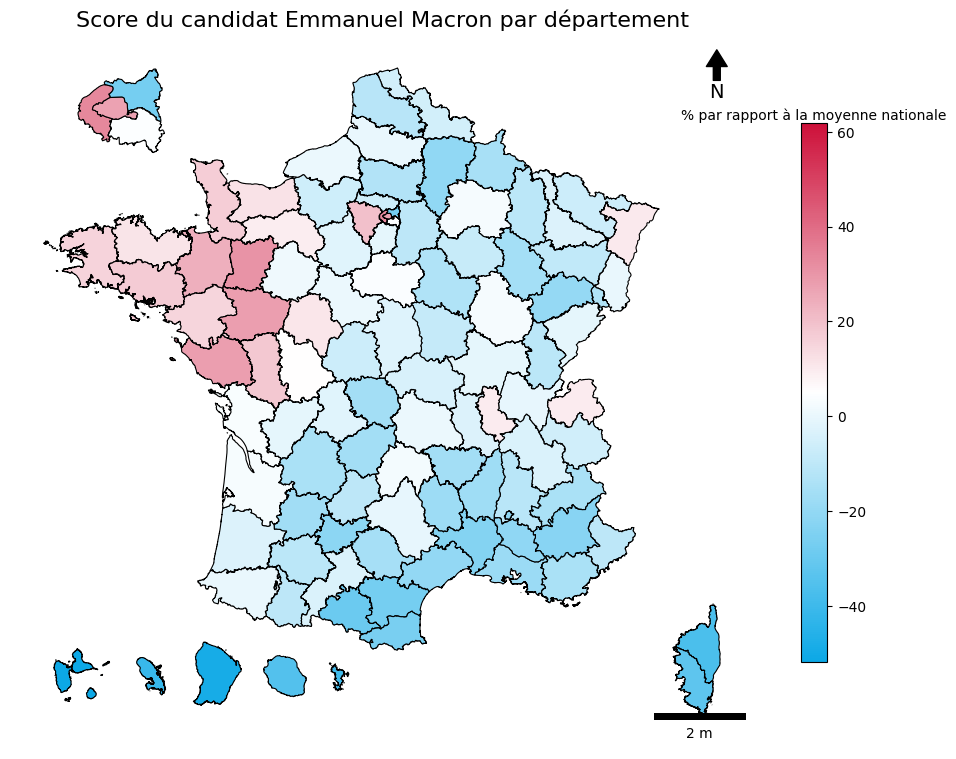

In [23]:
cartographie.afficher_resultats_filtre_candidat(df_score=score_departements, candidat="Emmanuel Macron", afficher_carte=True)

e:\ENSAI\2A\semestre2\python_4_data_science\venv1\Lib\site-packages\matplotlib_scalebar\scalebar.py:457: UserWarning: Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the warning with rotation='horizontal-only'.
  warnings.warn(


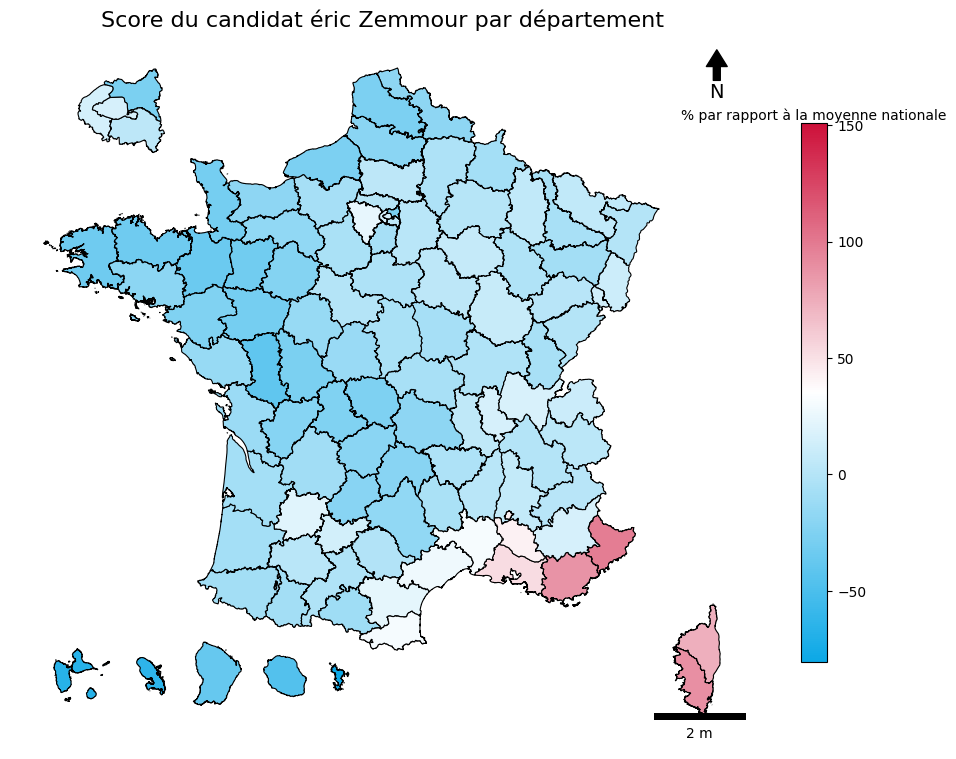

In [24]:
cartographie.afficher_resultats_filtre_candidat(df_score=score_departements, candidat="éric Zemmour", afficher_carte=True)